In [2]:
import pandas as pd
import numpy as np
import matplotlib as mpl
from matplotlib import  pyplot as plt 

In [287]:
# base_dir = "../../artifacts/2024-02-s22/experiments/1-accuracy-curves-pcaprca"
# base_dir = "../../artifacts/2024-02-s22/experiments/2-accuracy-curves-pcaprca-logitonehot"
# base_dir = "../../artifacts/2024-02-s22/experiments/3-accuracy-curves-pcaprca-invlogit"
# base_dir = "../../artifacts/2024-02-s22/experiments/4-accuracy-curves-normactctx"
# base_dir = "../../artifacts/2024-02-s22/experiments/5-accuracy-curves-drsanorm"
# base_dir = "../../artifacts/2024-02-s22/experiments/6-accuracy-curves-scaling"
# 
base_dir = "../../artifacts/2024-02-s22/experiments/7-accuracy-curves-logit-comparison"

In [288]:
def read_data(logit_mod, dataset, model, layer, basis_name, gamma=0.25):
    model = model
    layer = layer
    df = pd.read_csv(
        f"{base_dir}/{dataset}/{model}/{logit_mod}/{layer}/{basis_name}--gamma{gamma}.csv"
    )
    
    df["ref_acc"] = df[df.k == df.k.max()]["acc"].values[0]
    return df

read_data(
    logit_mod="zeroevidence",
    dataset="cifar100-people",
    model="cifar100-resnet18-v1",
    layer="layer1",
    basis_name="pca",
)

,layer,k,acc,ref_acc
0,layer1,1,0.200,0.62
1,layer1,2,0.192,0.62
2,layer1,3,0.290,0.62
3,layer1,4,0.334,0.62
4,layer1,5,0.390,0.62
5,layer1,6,0.464,0.62
6,layer1,7,0.484,0.62
7,layer1,8,0.532,0.62
8,layer1,9,0.552,0.62
9,layer1,10,0.552,0.62


In [289]:
def find_ratios(names):
    
    arr = []
    
    for t in names:
        m = re.match(r"pca([\.\d]+)prcasortabs", t)
        if m:
            arr.append(float(m.group(1)))
            
    
    return arr

find_ratios([
        "pca",
        "prcasortabs",
        "pca0.1prcasortabs",
        "pca0.25prcasortabs",
        "pca0.5prcasortabs",
        "pca1.0prcasortabs",
    ])

[0.1, 0.25, 0.5, 1.0]

In [251]:
np.argwhere(np.array([0.1, 0.25, 0.5, 1.0]) == 0.5).reshape(-1)[0]

2

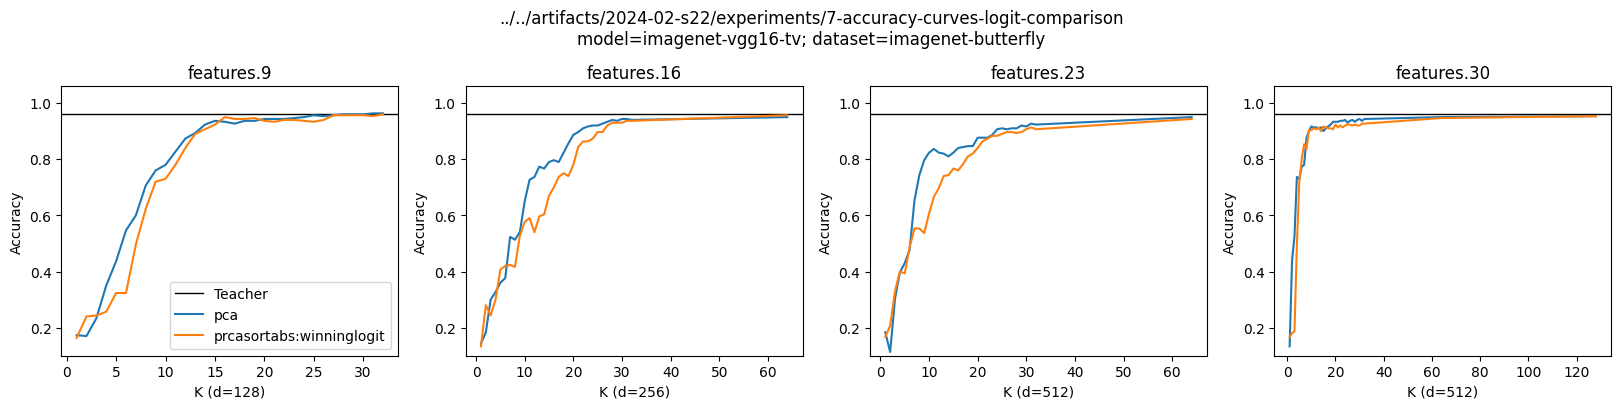

In [344]:
import re

def alias(name, logit_mod):
    if name == "pca":
        return name
    else:
        return f"{name}:{logit_mod}"


def ls(logit_mod):
    
    if logit_mod == "zeroevidence":
        return ":"
    elif logit_mod == "winningonehot":
        return "--"
    elif logit_mod == "winninglogit":
        return "-"
    elif logit_mod == "allclasses":
        return "-."
    else:
        raise
        
def viz(
    dataset,
    model,
    arr_layers,
    arr_basis_names = [
#         ("pca",
#         "prcasortabs",
#         "pca0.1prcasortabs",
#         "pca0.25prcasortabs",
#         "pca0.5prcasortabs",
#         "pca1.0prcasortabs",
    ]
):
    
    ncols = len(arr_layers)
    plt.figure(figsize=(5*ncols, 3.5))
    plt.suptitle(f"{base_dir}\nmodel={model}; dataset={dataset}", y=1.1)
    
    
#     arr_ratios = np.array(find_ratios(arr_basis_names))
#     color_index = np.linspace(0.25, 1, len(arr_ratios))
#     cmap_reds = mpl.colormaps.get_cmap("Reds")

#     def color(name):
#         if name == "pca":
#             return "blue"
#         elif name == "prcasortabs":
#             return "red"
#         elif re.match(r"pca([\.\d]+)prcasortabs", name):
#             ratio = float(re.match(r"pca([\.\d]+)prcasortabs", name).group(1))

#             ix = np.argwhere(arr_ratios == ratio).reshape(-1)[0]
#             return cmap_reds(color_index[ix])
#             return mpl.colormaps.get_cmap("Reds")(ratio + 0.1)
#         else:
#             raise
        
    
    
    
    for lix, (layer, max_k) in enumerate(arr_layers):
        plt.subplot(1, ncols, lix +1)
        
        plt.title(layer)
        
        for bix, (basis_name, logit_mod) in enumerate(arr_basis_names):
            df = read_data(
                logit_mod=logit_mod,
                dataset=dataset,
                model=model,
                layer=layer,
                basis_name=basis_name
            )
            dims = df.k.max()
                        
            if bix == 0:
                ref_acc = df["ref_acc"].values[0]
                plt.axhline(
                    ref_acc, ls="-", label="Teacher", 
                    color="black",
                    lw=1
                )
                plt.ylim([0.1, ref_acc+0.1])
            _df = df[df.k <= max_k]

            plt.plot(
                _df.k,
                _df.acc,
                label=alias(basis_name, logit_mod),
                
#                 color="blue" if basis_name == "pca" else "red",
#                 ls=ls(logit_mod)
            )
            plt.xlabel(f"K (d={dims})")
        
        # with ratio
#         arr_steps = np.floor(np.array(arr_ratios) * dims)
        
#         for _ix, _d in enumerate(arr_steps):
#             if _d < max_k:
#                 plt.axvline(_d, ls=":", lw=1, color="gray")
#                 plt.text(
#                     _d, ref_acc + 0.01, f"{arr_ratios[_ix] * 100:.1f}%", fontsize="small",
#                     ha="center"
#                 )
        plt.ylabel("Accuracy")
        
        if lix == 0:
            plt.legend()
# viz(
#     dataset="cifar100-people",
#     model="cifar100-resnet18-v1",
#     arr_layers=[
#         ("layer1", 32),
#         ("layer2", 32),
#         ("layer3", 64),
#         ("layer4", 5),
#     ],
#     arr_basis_names = [
#         ("pca", "winninglogit"),
#         ("prcasortabs", "winninglogit"),
#         ("prcasortabs", "winningonehot"),
#         ("prcasortabs", "zeroevidence"),
#     ]
# )

viz(
    dataset="imagenet-butterfly",
    model="imagenet-vgg16-tv",
    arr_layers=[
        ("features.9", 32),
        ("features.16", 64),
        ("features.23", 64),
        ("features.30", 128),
    ],
     arr_basis_names = [
        ("pca", "winninglogit"),
        ("prcasortabs", "winninglogit"),
#         ("prcasortabs", "winningonehot"),
#         ("prcasortabs", "zeroevidence"),
#         ("prcasortabs", "allclasses"),
#          ("prcasortabs", "winninglogitotherneg")

    ]
)

In [331]:
# viz(
#     dataset="imagenet-butterfly",
#     model="imagenet-vgg16-tv",
#     arr_layers=[
#         ("features.9", 32),
#         ("features.16", 64),
#         ("features.23", 64),
#         ("features.30", 32),
#     ],
#      arr_basis_names = [
#         ("pca", "winninglogit"),
#         ("prcasortabs", "winninglogit"),
#         ("prcasortabs", "winningonehot"),
#         ("prcasortabs", "zeroevidence"),
# #         ("prcasortabs", "allclasses"),

#     ]
# )

In [310]:
raise

RuntimeError: No active exception to reraise

END

In [215]:
# viz(
#     dataset="imagenet-butterfly",
#     model="imagenet-resnet18-tv",
#     arr_layers=[
#         ("layer1", 32),
#         ("layer2", 64),
#         ("layer3", 64),
#         ("layer4", 32),
#     ],
#     arr_basis_names = [
#         "pca",
#         "prcasortabs",
#         "pca0.1prcasortabs",
#         "pca0.25prcasortabs",
#         "pca0.5prcasortabs",
# #         "pca0.75prcasortabs",
#     ]
# )

In [216]:
# viz(
#     dataset="imagenet-butterfly",
#     model="imagenet-resnet50-tv",
#     arr_layers=[
#         ("layer1", 32),
#         ("layer2", 64),
#         ("layer3", 64),
#         ("layer4", 32),
#     ],
#       arr_basis_names = [
#         "pca",
#         "prcasortabs",
#         "pca0.1prcasortabs",
#         "pca0.25prcasortabs",
#         "pca0.5prcasortabs",
#         "pca0.75prcasortabs",
#     ]
# )

In [309]:
# viz(
#     dataset="imagenet-butterfly",
#     model="imagenet-vgg16-tv",
#     arr_layers=[
#         ("features.9", 32),
#         ("features.16", 64),
#         ("features.23", 64),
#         ("features.30", 32),
#     ],
#      arr_basis_names = [
#         "pca",
#         "prcasortabs",
         
#         "pca0.025prcasortabs",
#         "pca0.05prcasortabs",
        
#          "pca0.1prcasortabs",
# #         "v2pca0.1prcasortabs",

# # #         "pca0.125prcasortabs",

#         "pca0.25prcasortabs",
# #         "v2pca0.25prcasortabs",

# #         "pca0.5prcasortabs",
# #         "pca0.75prcasortabs",
#     ]
# )

In [164]:
512 * 0.05

25.6

In [109]:
256* 0.025

6.4